# Session 5 — Demo 2 — One line between classes

**What this demo covers.** A bank rarely asks "how much?"; it asks "yes or no?". Will this firm go bankrupt? We meet a new dataset (your turf this time: financial ratios of 6,819 companies), remember how Edward Altman answered the question in 1968 with one line, and see why last hour's regression can't output a probability. Then logistic regression: the same line pushed through a sigmoid. We read its coefficients and their significance, see who uses it in real banks, and hit the problem of a model that is 97% accurate and nearly useless.

**Data.** `data/bankruptcy/taiwan_bankruptcy.csv`. Where it comes from is section 1.

**How to run.** Locally: top to bottom. Colab: uncomment the two `git clone` lines in the setup cell. Needs `statsmodels`, `scikit-learn` and `seaborn`, all preinstalled in Colab.

## 0. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from matplotlib.ticker import AutoMinorLocator

# the Taiwan bankruptcy dataset (sessions 5 to 7)
DATA = Path("../../data/bankruptcy")

# --- Google Colab? Uncomment these two lines to fetch the course repo: ---
# !git clone https://github.com/seemsGoodNow/hse-data-science-course.git course
# DATA = Path("course/data/bankruptcy")

# missing a library? uncomment:
# %pip install pandas matplotlib seaborn statsmodels scikit-learn

# one colour per class, used in every chart below
HEALTHY_COLOR = "#4a7ebb"
BANKRUPT_COLOR = "#c0392b"

In [2]:
def make_ax_better(ax, minor=""):
    """Tidy one chart: drop the top/right frame, add a light grid.

    minor="x", "y" or "xy" also adds small ticks between the labelled ones.
    """
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    if "x" in minor:
        ax.xaxis.set_minor_locator(AutoMinorLocator())
    if "y" in minor:
        ax.yaxis.set_minor_locator(AutoMinorLocator())
    if minor:
        ax.tick_params(which="minor", length=2.5)
        ax.tick_params(which="major", length=5)
        ax.grid(which="minor", linewidth=0.15, color="tab:grey", alpha=0.25)
    ax.grid(linewidth=0.5, color="tab:grey", alpha=0.25)

---

## 1. Where the data comes from

Before you trust a column, find the page that describes it.

- **Source:** the Taiwan Economic Journal, companies listed in Taiwan, 1999–2009. Bankruptcy is defined by the rules of the Taiwan Stock Exchange.
- **Official page:** [UCI Machine Learning Repository, dataset 572](https://archive.ics.uci.edu/dataset/572/taiwanese+bankruptcy+prediction), with a description of every column (CC BY 4.0).
- **The paper behind it:** Liang, Lu, Tsai and Shih, *Financial ratios and corporate governance indicators in bankruptcy prediction: A comprehensive study*, European Journal of Operational Research, 2016 ([doi.org/10.1016/j.ejor.2016.01.012](https://doi.org/10.1016/j.ejor.2016.01.012)).
- **A copy on Kaggle:** [Company Bankruptcy Prediction](https://www.kaggle.com/datasets/fedesoriano/company-bankruptcy-prediction).

**Finding data yourself.** Three good places to start:

- **UCI Machine Learning Repository** ([archive.ics.uci.edu](https://archive.ics.uci.edu)): older, well-documented tables, each with a page describing its columns.
- **Kaggle Datasets** ([kaggle.com/datasets](https://www.kaggle.com/datasets)): the biggest collection of tables; quality varies, so read the description and the discussion.
- **Hugging Face Datasets** ([huggingface.co/datasets](https://huggingface.co/datasets?other=finance), link filtered by the tag *finance*): thousands of datasets, strongest for text (session 7 uses text). The `datasets` package loads any of them with `load_dataset("owner/name")`. We found no official copy of this bankruptcy dataset there; community copies of popular datasets do appear, so check who uploaded one before you trust it.

In Colab, the `ucimlrepo` package downloads any UCI dataset in two lines:

```python
# %pip install ucimlrepo
from ucimlrepo import fetch_ucirepo
bankruptcy = fetch_ucirepo(id=572)
```

An AI assistant with web search is fast at finding candidates ("find public datasets about corporate bankruptcy with financial ratios"). Then open the original page yourself: assistants sometimes invent column descriptions, and a wrong description is worse than none.

## 2. First contact

In [3]:
firms = pd.read_csv(DATA / "taiwan_bankruptcy.csv")
firms.shape

(6819, 96)

In [4]:
firms.head(3)

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474


6,819 companies and 96 columns: the target `Bankrupt?` (1 = went bankrupt) plus 95 financial columns. Two things to notice.

- **The first rows are all bankrupt firms.** The file is not shuffled, so its top is not a fair sample.
- **These are not raw ratios.** `Operating Profit Rate` is 0.999 for all three firms, bankrupt ones included. The published dataset was rescaled, and most columns run from 0 to 1. So 0.50 means "somewhere in the middle of the pack", not 50%. Directions survive: higher is still higher. Units don't. (A few cells below, we find where one real threshold landed.)

Let's grab a column:

```python
# firms["ROA(C) before interest and depreciation before interest"]   # 💥 KeyError?!
```

The name *looks* right. `list(firms.columns[:4])` prints the first four names with quotes, so every character is visible:

In [5]:
list(firms.columns[:4])

['Bankrupt?',
 ' ROA(C) before interest and depreciation before interest',
 ' ROA(A) before interest and % after tax',
 ' ROA(B) before interest and depreciation after tax']

**Leading spaces**, invisible in `head()`. The primer's `.strip()` removes them; `.str` in front applies it to every name at once.

In [6]:
firms.columns = firms.columns.str.strip()
firms["ROA(C) before interest and depreciation before interest"].head(3)

0    0.370594
1    0.464291
2    0.426071
Name: ROA(C) before interest and depreciation before interest, dtype: float64

Next routine stop: does any column know only one answer?

In [7]:
firms.nunique().sort_values().head(3)

Net Income Flag          1
Bankrupt?                2
Liability-Assets Flag    2
dtype: int64

`Net Income Flag` has one value, 1, for all 6,819 firms. The UCI page defines it as *"one if net income is negative for the last two years, zero otherwise"*. That would mean every firm lost money two years running, including the most profitable ones by every other column. **The column contradicts its own description.** It is broken, and that, not just "it never changes", is why it goes.

In [8]:
firms = firms.drop(columns=["Net Income Flag"])

`Liability-Assets Flag` should be 1 when liabilities exceed assets. Is it consistent with the debt ratio? Compare the debt ratio of the flagged firms with the ten highest debt ratios in the file:

In [9]:
flagged_debt = (
    firms[firms["Liability-Assets Flag"] == 1]["Debt ratio %"]
    .sort_values(ascending=False)
)
highest_debt = firms["Debt ratio %"].sort_values(ascending=False).head(10)

print(
    f"debt ratio of the {len(flagged_debt)} flagged firms:\n"
    f"  {flagged_debt.round(3).tolist()}\n"
    f"ten highest debt ratios in the file:\n"
    f"  {highest_debt.round(3).tolist()}"
)

debt ratio of the 8 flagged firms:
  [1.0, 0.525, 0.338, 0.332, 0.327, 0.321, 0.313, 0.305]
ten highest debt ratios in the file:
  [1.0, 0.525, 0.338, 0.332, 0.327, 0.321, 0.313, 0.305, 0.295, 0.294]


The flag sits on **exactly the eight most indebted firms**, and not on the ninth (0.295). This column is honest. It also shows the rescaling at work: the real line "liabilities = assets" sits at about **0.30** on this axis. Remember 0.30.

And the most important number of the dataset:

In [10]:
bankrupt_share = firms["Bankrupt?"].mean()
print(
    f"bankrupt: {bankrupt_share:.1%} of firms "
    f"({firms['Bankrupt?'].sum()} of {len(firms):,})"
)

bankrupt: 3.2% of firms (220 of 6,819)


**3.2% bankrupt.** Keep that number in your head; section 11 shows why it matters.

## 3. Altman's Z-score: the 1968 answer

In 1968 Edward Altman, then at New York University, published the first famous bankruptcy model built from financial ratios. He took **66 US manufacturers, 33 that went bankrupt between 1946 and 1965 and 33 that didn't**, and searched for the combination of five ratios that best told the two groups apart. In the commonly quoted form:

| ratio | what it measures | weight |
|---|---|---|
| working capital / total assets | liquidity buffer | 1.2 |
| retained earnings / total assets | accumulated cushion | 1.4 |
| EBIT / total assets | profitability | 3.3 |
| market value of equity / total liabilities | cushion against debt | 0.6 |
| sales / total assets | how hard assets work | 1.0 |

**Z = the weighted sum** of the five ratios. Above 2.99: safe. Below 1.81: distress. In between, what Altman called the *zone of ignorance*.

How did he find the weights? With *multiple discriminant analysis*: the method looks for the weighted sum that best **separates** the two groups. On a picture with two ratios, that is one straight line between bankrupt and healthy firms. That is exactly what tonight's model does, sixty years later.

**Reference.** Altman, E. I. (1968). *Financial Ratios, Discriminant Analysis and the Prediction of Corporate Bankruptcy.* The Journal of Finance, 23(4), 589–609. [doi.org/10.1111/j.1540-6261.1968.tb00843.x](https://doi.org/10.1111/j.1540-6261.1968.tb00843.x). Altman later published versions for private firms and for non-manufacturers (known as Z′ and Z″).

*A warning about words:* Altman's **Z-score** has nothing to do with the **z-score** from Demo 1 (a value minus the mean, divided by the std). Same letter, two different ideas.

We can't compute the real Z here: the ratios are rescaled, and there is no market value of equity. But we can refit his idea.

## 4. 🧪 Toy example: one line between two classes

A **made-up** picture first, where we control everything. Two groups of invented firms, two ratios each. Everything named `toy_…` in this section is made up.

In [11]:
toy_rng = np.random.default_rng(7)
toy_healthy = pd.DataFrame({
    "debt": toy_rng.normal(0.35, 0.10, 60),
    "profit": toy_rng.normal(0.60, 0.10, 60),
})
toy_bankrupt = pd.DataFrame({
    "debt": toy_rng.normal(0.65, 0.10, 20),
    "profit": toy_rng.normal(0.35, 0.10, 20),
})
toy_healthy.head(3)

,debt,profit
0,0.350123,0.620314
1,0.379875,0.553669
2,0.322586,0.612727


Our rule, a straight line: **a firm is called bankrupt when its debt is higher than its profitability** (`debt > profit`). Everything on one side of the line gets one class, everything on the other side the other class. The shading shows the class each side gets.

Three chart tools you'll see from here on: `ax.fill_between` and `ax.axvspan` shade an area, `ax.text` writes a label at given coordinates, and `ax.set_xlim` / `ax.set_ylim` fix the visible range of an axis.

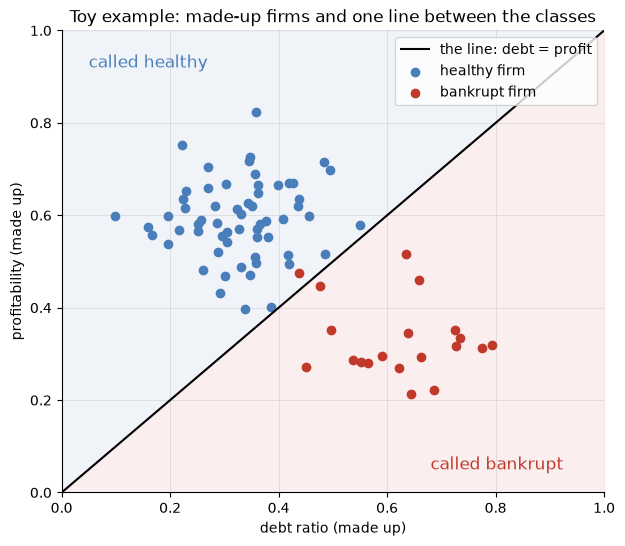

In [12]:
toy_line_ends = np.array([0.0, 1.0])

fig, ax = plt.subplots(figsize=(7, 6))
# the rule "debt > profit" splits the square along the diagonal
ax.fill_between(
    toy_line_ends,
    toy_line_ends,
    1,
    color=HEALTHY_COLOR,
    alpha=0.08,
)
ax.fill_between(
    toy_line_ends,
    0,
    toy_line_ends,
    color=BANKRUPT_COLOR,
    alpha=0.08,
)
ax.plot(
    toy_line_ends,
    toy_line_ends,
    color="black",
    linewidth=1.5,
    label="the line: debt = profit",
)
ax.scatter(
    toy_healthy["debt"],
    toy_healthy["profit"],
    color=HEALTHY_COLOR,
    label="healthy firm",
)
ax.scatter(
    toy_bankrupt["debt"],
    toy_bankrupt["profit"],
    color=BANKRUPT_COLOR,
    label="bankrupt firm",
)
ax.text(
    0.05,
    0.92,
    "called healthy",
    color=HEALTHY_COLOR,
    fontsize=12,
)
ax.text(
    0.68,
    0.05,
    "called bankrupt",
    color=BANKRUPT_COLOR,
    fontsize=12,
)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title("Toy example: made-up firms and one line between the classes")
ax.set_xlabel("debt ratio (made up)")
ax.set_ylabel("profitability (made up)")
ax.legend(loc="upper right")
make_ax_better(ax)
plt.show()

In [13]:
toy_healthy_called_bankrupt = (toy_healthy["debt"] > toy_healthy["profit"]).sum()
toy_bankrupt_called_healthy = (toy_bankrupt["debt"] <= toy_bankrupt["profit"]).sum()
print(
    f"healthy firms on the bankrupt side: "
    f"{toy_healthy_called_bankrupt} of {len(toy_healthy)}\n"
    f"bankrupt firms on the healthy side: "
    f"{toy_bankrupt_called_healthy} of {len(toy_bankrupt)}"
)

healthy firms on the bankrupt side: 0 of 60
bankrupt firms on the healthy side: 1 of 20


The parallel with Demo 1: there the line went **through** the points and predicted a number. Here it goes **between** two groups and predicts a class. A model for classes separates the groups as well as it can. What "well" should mean turns out to be tricky, and section 11 shows why. Real data will be messier, as we will see.

## 5. Back to the real data: the same schema, and the split

The schema from Demo 1 doesn't change:

```
 fit:      X (features)  +  y (target)   ──▶  fitted model
 predict:  X_new                          ──▶  fitted model  ──▶  ŷ
```

Two things are new.

- **The target is a class.** `y` is `Bankrupt?`: 1 or 0, yes or no. The features `X` are the ratios.
- **We now grade predictions.** In Demo 1 we *explained* one week of tasks and read the coefficients. Now we want to predict firms the model has never seen, and check how often it is right. So we hold some firms back: the **train set** is what the model learns from, the **test set** is what we grade it on, like a student tested on problems they haven't solved before. The rule: **split before everything else.**

`train_test_split` from `scikit-learn` shuffles the rows and cuts them in two. It returns four pieces in a fixed order, so four names on the left. `test_size=0.3` sends 30% of the firms to the test set; `random_state=42` fixes the shuffle, like the seed of `rng` in session 4; `stratify=y` keeps the same 3.2% of bankrupt firms in both parts.

In [14]:
from sklearn.model_selection import train_test_split

y = firms["Bankrupt?"]
X = firms.drop(columns=["Bankrupt?"])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y,
)
print(
    f"train: {len(X_train):,} firms, {y_train.sum()} bankrupt\n"
    f"test:  {len(X_test):,} firms, {y_test.sum()} bankrupt"
)

train: 4,773 firms, 154 bankrupt
test:  2,046 firms, 66 bankrupt


## 6. Why last hour's line can't do this

The obvious first try: code bankrupt as 1 and healthy as 0, and fit Demo 1's least-squares line on the debt ratio:

$$\hat y_i = \beta_0 + \beta_1 \cdot \text{debt}_i$$

and call $\hat y$ "the probability of bankruptcy". Same `statsmodels` steps as in Demo 1, `sm.add_constant` included (without it the line would be forced through zero). Let's see what it says. In the chart, `ax.axhspan` shades a horizontal band: the impossible zone below zero.

In [15]:
DEBT = "Debt ratio %"

debt_line = sm.OLS(y_train, sm.add_constant(X_train[[DEBT]])).fit()
line_guess = debt_line.predict(sm.add_constant(X_test[[DEBT]]))

print(
    f"lowest 'probability': {line_guess.min():.3f}\n"
    f"test firms with a negative 'probability': {(line_guess < 0).mean():.0%}"
)

lowest 'probability': -0.058
test firms with a negative 'probability': 25%


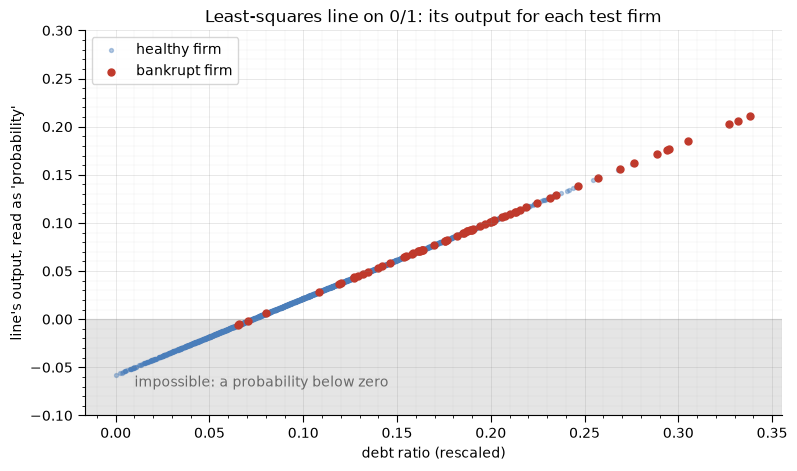

In [16]:
# every test firm is a dot ON the line: x = its debt ratio, y = what the line says;
# the colour is what really happened to the firm
is_bankrupt = (y_test == 1).to_numpy()

fig, ax = plt.subplots(figsize=(9, 5))
ax.axhspan(
    -0.1,
    0,
    color="grey",
    alpha=0.2,
)
ax.scatter(
    X_test[DEBT][~is_bankrupt],
    line_guess[~is_bankrupt],
    s=8,
    alpha=0.4,
    color=HEALTHY_COLOR,
    label="healthy firm",
)
ax.scatter(
    X_test[DEBT][is_bankrupt],
    line_guess[is_bankrupt],
    s=25,
    color=BANKRUPT_COLOR,
    label="bankrupt firm",
)
ax.text(
    0.01,
    -0.07,
    "impossible: a probability below zero",
    color="dimgrey",
)
ax.set_ylim(-0.1, 0.3)
ax.set_title("Least-squares line on 0/1: its output for each test firm")
ax.set_xlabel("debt ratio (rescaled)")
ax.set_ylabel("line's output, read as 'probability'")
ax.legend(loc="upper left")
make_ax_better(ax, minor="xy")
plt.show()

For a quarter of the test firms the line says the probability of bankruptcy is **below zero**. A straight line runs from minus infinity to plus infinity; a probability lives between 0 and 1. We need something that **bends the line into that range**.

## 7. The sigmoid and logistic regression

The bending function is the **sigmoid** (also called the *logistic function*, which gives the model its name):

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Here $z$ is any number, the "score", and $\sigma(z)$ is always between 0 and 1. In Python, `np.exp(x)` is e to the power x.

🧪 **Toy example:** seven made-up scores, to see what the sigmoid does.

In [17]:
toy_scores = np.array([-6, -3, -1, 0, 1, 3, 6])
toy_probabilities = 1 / (1 + np.exp(-toy_scores))

pd.DataFrame({
    "score": toy_scores,
    "probability": toy_probabilities.round(3),
})

,score,probability
0,-6,0.002
1,-3,0.047
2,-1,0.269
3,0,0.500
4,1,0.731
5,3,0.953
6,6,0.998


Very negative scores become almost 0, zero becomes exactly 0.5, very positive scores become almost 1. Any number goes in, a probability comes out. To draw the whole curve we need many x-values: `np.linspace(a, b, n)` makes `n` evenly spaced numbers from `a` to `b`.

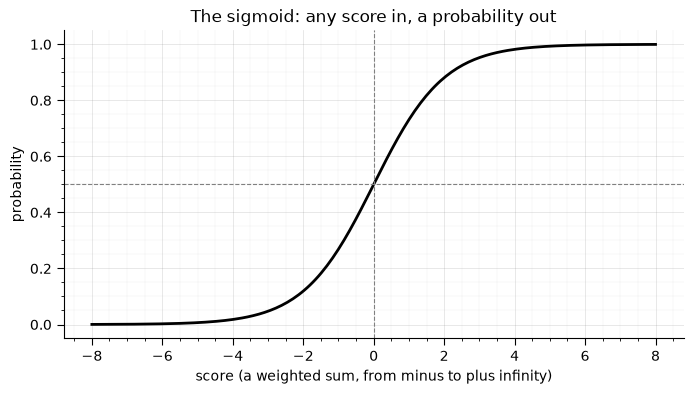

In [18]:
score_axis = np.linspace(-8, 8, 200)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    score_axis,
    1 / (1 + np.exp(-score_axis)),
    color="black",
    linewidth=2,
)
ax.axhline(
    0.5,
    color="grey",
    linestyle="--",
    linewidth=0.8,
)
ax.axvline(
    0,
    color="grey",
    linestyle="--",
    linewidth=0.8,
)
ax.set_title("The sigmoid: any score in, a probability out")
ax.set_xlabel("score (a weighted sum, from minus to plus infinity)")
ax.set_ylabel("probability")
make_ax_better(ax, minor="xy")
plt.show()

**Back to the real data. Logistic regression is exactly two steps:**

1. the same weighted sum as in Demo 1: $z_i = \beta_0 + \beta_1 \cdot \text{debt}_i$;
2. push it through the sigmoid: $p_i = \sigma(z_i)$, the probability that firm $i$ goes bankrupt.

The model picks $\beta_0$ and $\beta_1$ that make the bankruptcies we actually observed as likely as possible (*maximum likelihood*: the classification cousin of least squares). In `statsmodels` it is `sm.Logit` instead of `sm.OLS`, with the same `sm.add_constant` for $\beta_0$; `disp=0` silences the fitting log. The same small function as in Demo 1 prints the coefficients and their p-values.

In [19]:
def summarize_coefficients(model):
    """Coefficient and p-value per feature of a fitted statsmodels model."""
    return pd.DataFrame({
        "coefficient": model.params.round(4),
        "p_value": model.pvalues.round(4),
    })


debt_model = sm.Logit(y_train, sm.add_constant(X_train[[DEBT]])).fit(disp=0)
summarize_coefficients(debt_model)

,coefficient,p_value
const,-7.004,0.0
Debt ratio %,24.805,0.0


The weight is positive and the p-value is tiny: more debt, more risk, and not by luck. Now read it like a credit officer: what probability does the model give at different debt levels?

In [20]:
debt_levels = pd.DataFrame({DEBT: [0.05, 0.11, 0.20, 0.30, 0.50]})
debt_levels["probability_of_bankruptcy"] = debt_model.predict(
    sm.add_constant(debt_levels)
).round(3)
debt_levels

,Debt ratio %,probability_of_bankruptcy
0,0.05,0.003
1,0.11,0.014
2,0.20,0.115
3,0.30,0.608
4,0.50,0.995


0.3% at a low debt ratio, **1.4% at the median firm (0.11)**, 12% at 0.20, and **61% at 0.30, exactly where liabilities equal assets.** The flag from section 2 and the model agree.

Now the picture that matters most tonight: **who gets which class.** The model calls a firm bankrupt when its probability is at least 0.5. On the debt axis that happens past one cut-off point: to its right the background is red (called bankrupt), to its left blue (called healthy).

How to read it: **every test firm is a dot on the sigmoid**, at its own debt ratio, at the probability the model gives it. The colour of the dot is what *really* happened. A red dot on a blue background is a bankruptcy the model missed.

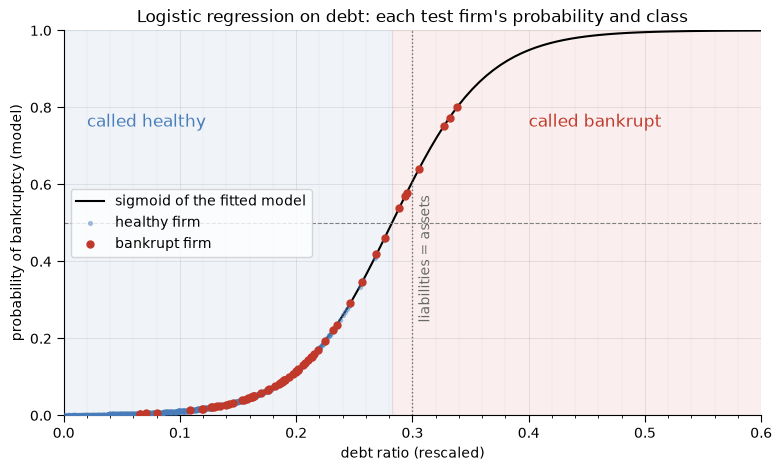

cut-off: debt ratio 0.282
firms with a debt ratio above 0.6 not shown: 0


In [21]:
# probability = 0.5 exactly where the score is 0: beta_0 + beta_1 * debt = 0
debt_cutoff = -debt_model.params["const"] / debt_model.params[DEBT]

AXIS_LIMIT = 0.6
debt_axis = np.linspace(0, AXIS_LIMIT, 100)
debt_curve = debt_model.predict(
    sm.add_constant(pd.DataFrame({DEBT: debt_axis}))
)
test_probability = debt_model.predict(sm.add_constant(X_test[[DEBT]]))
hidden = (X_test[DEBT] > AXIS_LIMIT).sum()

fig, ax = plt.subplots(figsize=(9, 5))
ax.axvspan(
    0,
    debt_cutoff,
    color=HEALTHY_COLOR,
    alpha=0.08,
)
ax.axvspan(
    debt_cutoff,
    AXIS_LIMIT,
    color=BANKRUPT_COLOR,
    alpha=0.08,
)
ax.plot(
    debt_axis,
    debt_curve,
    color="black",
    linewidth=1.5,
    label="sigmoid of the fitted model",
)
ax.scatter(
    X_test[DEBT][~is_bankrupt],
    test_probability[~is_bankrupt],
    s=8,
    alpha=0.4,
    color=HEALTHY_COLOR,
    label="healthy firm",
    zorder=3,
)
ax.scatter(
    X_test[DEBT][is_bankrupt],
    test_probability[is_bankrupt],
    s=25,
    color=BANKRUPT_COLOR,
    label="bankrupt firm",
    zorder=4,
)
ax.axhline(
    0.5,
    color="grey",
    linestyle="--",
    linewidth=0.8,
)
ax.axvline(
    0.30,
    color="dimgrey",
    linestyle=":",
    linewidth=1,
)
ax.text(
    0.305,
    0.25,
    "liabilities = assets",
    color="dimgrey",
    rotation=90,
)
ax.text(
    0.02,
    0.75,
    "called healthy",
    color=HEALTHY_COLOR,
    fontsize=12,
)
ax.text(
    0.40,
    0.75,
    "called bankrupt",
    color=BANKRUPT_COLOR,
    fontsize=12,
)
ax.set_xlim(0, AXIS_LIMIT)
ax.set_ylim(0, 1)
ax.set_title("Logistic regression on debt: each test firm's probability and class")
ax.set_xlabel("debt ratio (rescaled)")
ax.set_ylabel("probability of bankruptcy (model)")
ax.legend(loc="center left")
make_ax_better(ax, minor="x")
plt.show()

print(
    f"cut-off: debt ratio {debt_cutoff:.3f}\n"
    f"firms with a debt ratio above {AXIS_LIMIT} not shown: {hidden}"
)

Where are the healthy firms? The blue smear under the curve, from 0 to about 0.25, is 1,980 of them. The missed bankruptcies sit right among them.

Count the four kinds of test firm: each firm is either bankrupt or not, and either called bankrupt or not. We build the table one step at a time.

In [22]:
debt_verdicts = pd.DataFrame({
    "actually_bankrupt": y_test.to_numpy() == 1,
    "called_bankrupt": X_test[DEBT].to_numpy() >= debt_cutoff,
})
debt_verdicts.head(3)

,actually_bankrupt,called_bankrupt
0,False,False
1,False,False
2,False,False


In [23]:
pd.crosstab(
    debt_verdicts["actually_bankrupt"],
    debt_verdicts["called_bankrupt"],
)

called_bankrupt,False,True
actually_bankrupt,,
False,1980,0
True,59,7


Read the table: rows are the truth, columns are the model's call. Most bankrupt firms sit in the **"called healthy"** column: the red dots left of the cut-off in the picture. Their debt alone doesn't look dangerous. One ratio is not enough, and next week this table gets a proper name.

## 8. ⏭ Two ratios: the boundary is a line again

Add profitability (ROA). The score is now $z = \beta_0 + \beta_1 \cdot \text{debt} + \beta_2 \cdot \text{ROA}$, and the firms the model calls 50/50 are those where $z = 0$. That set of points is a **straight line** on the debt–ROA plane: Altman's picture, fitted by the computer. Here each dot is a test firm at its two ratios; the background shows the class the model gives to that spot.

In [24]:
ROA = "ROA(C) before interest and depreciation before interest"

two_ratio_model = sm.Logit(y_train, sm.add_constant(X_train[[DEBT, ROA]])).fit(disp=0)
summarize_coefficients(two_ratio_model)

,coefficient,p_value
const,1.6790,0.0201
Debt ratio %,19.2066,0.0000
ROA(C) before interest and depreciation before interest,-16.6425,0.0000


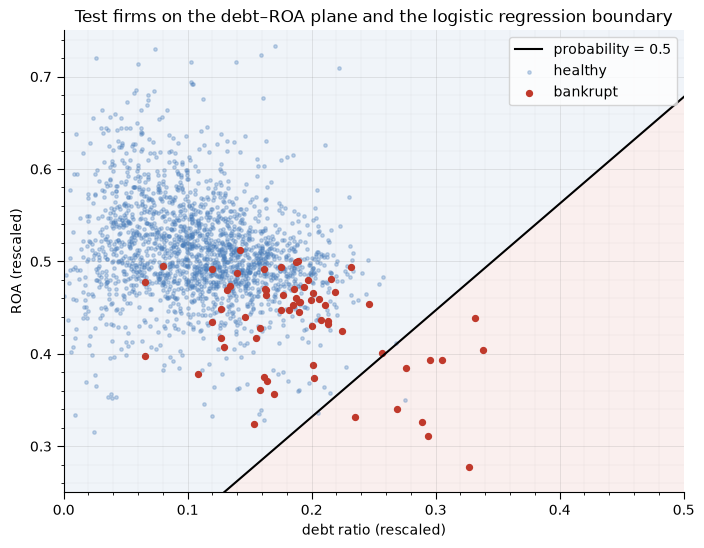

test firms outside the zoomed area, not shown: 8 of 2,046


In [25]:
# score = 0  <=>  ROA = -(start + w_debt * debt) / w_roa : a straight line
weights = two_ratio_model.params
debt_ends = np.array([0.0, 1.0])
boundary_roa = -(weights["const"] + weights[DEBT] * debt_ends) / weights[ROA]

debt_range = (0, 0.5)
roa_range = (0.25, 0.75)
is_shown = (
    X_test[DEBT].between(*debt_range)
    & X_test[ROA].between(*roa_range)
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.fill_between(
    debt_ends,
    boundary_roa,
    1,
    color=HEALTHY_COLOR,
    alpha=0.08,
)
ax.fill_between(
    debt_ends,
    0,
    boundary_roa,
    color=BANKRUPT_COLOR,
    alpha=0.08,
)
ax.plot(
    debt_ends,
    boundary_roa,
    color="black",
    linewidth=1.5,
    label="probability = 0.5",
)
ax.scatter(
    X_test[DEBT][is_shown & ~is_bankrupt],
    X_test[ROA][is_shown & ~is_bankrupt],
    s=6,
    alpha=0.3,
    color=HEALTHY_COLOR,
    label="healthy",
)
ax.scatter(
    X_test[DEBT][is_shown & is_bankrupt],
    X_test[ROA][is_shown & is_bankrupt],
    s=18,
    color=BANKRUPT_COLOR,
    label="bankrupt",
)
ax.set_xlim(*debt_range)
ax.set_ylim(*roa_range)
ax.set_title("Test firms on the debt–ROA plane and the logistic regression boundary")
ax.set_xlabel("debt ratio (rescaled)")
ax.set_ylabel("ROA (rescaled)")
ax.legend(loc="upper right")
make_ax_better(ax, minor="xy")
plt.show()

print(
    f"test firms outside the zoomed area, not shown: "
    f"{(~is_shown).sum()} of {len(X_test):,}"
)

Below the line: high debt, low profitability, called bankrupt. Three more bankruptcies cross the line: 10 of 66 now, against 7 with debt alone. Most of the red dots still sit in the healthy crowd: two ratios can't see everything.

## 9. Five ratios, and which of them matter

Back to Altman's five. Our data has no market prices, so we follow his logic with the closest columns:

| Altman's ratio | our column | expected sign in *our* model |
|---|---|---|
| working capital / total assets | `Working Capital to Total Assets` | − |
| retained earnings / total assets | `Retained Earnings to Total Assets` | − |
| EBIT / total assets | `ROA(C) before interest and depreciation before interest` | − |
| market value of equity / total liabilities | `Debt ratio %` (liabilities / assets) | **+** |
| sales / total assets | `Total Asset Turnover` | − |

**Watch the signs.** In Altman's Z a higher score means *safer*, so all his weights are positive. Our model predicts the probability of *bankruptcy*, so a ratio that protects gets a **negative** weight. `Debt ratio %` measures the opposite of Altman's equity cushion, so its weight should be positive.

The ratios live on different scales, so we standardize them as in Demo 1, using the **training** firms' mean and std for both parts (the test firms must not influence anything we learn).

In [26]:
FIVE_RATIOS = [
    "Working Capital to Total Assets",
    "Retained Earnings to Total Assets",
    ROA,
    "Total Asset Turnover",
    DEBT,
]

train_mean = X_train[FIVE_RATIOS].mean()
train_std = X_train[FIVE_RATIOS].std()
five_train = (X_train[FIVE_RATIOS] - train_mean) / train_std
five_test = (X_test[FIVE_RATIOS] - train_mean) / train_std

five_model = sm.Logit(y_train, sm.add_constant(five_train)).fit(disp=0)
summarize_coefficients(five_model)

,coefficient,p_value
const,-4.8810,0.0000
Working Capital to Total Assets,-0.2500,0.0323
Retained Earnings to Total Assets,0.1843,0.0098
ROA(C) before interest and depreciation before interest,-1.1572,0.0000
Total Asset Turnover,-0.6270,0.0000
Debt ratio %,1.0910,0.0000


Read it against the table:

- **ROA strongly negative, tiny p-value:** profitability protects. ✔
- **Debt ratio strongly positive:** leverage kills. ✔
- **Asset turnover negative:** efficient assets protect. ✔
- **Working capital negative**, p = 0.03: a weaker, but still real, effect. ✔
- **Retained earnings positive, p = 0.01?!** Significant, and with the *wrong* sign.

Demo 1's second trap again? Check the twins:

In [27]:
retained_vs_roa = X_train["Retained Earnings to Total Assets"].corr(X_train[ROA])
print(f"correlation of retained earnings and ROA: {retained_vs_roa:.2f}")

correlation of retained earnings and ROA: 0.63


**0.63.** Firms that earn well also tend to keep their earnings. The model splits the credit between the two relatives, and retained earnings end up with the wrong sign, *significantly*. A small p-value doesn't protect you from twins. (On its own, retained earnings get the negative weight finance expects: see ⚡ Extras.)

## 10. Who uses this in real life

Russian banks that calculate credit risk on internal ratings follow **Bank of Russia Regulation 483-P** ([cbr.ru](https://www.cbr.ru/faq_ufr/dbrnfaq/doc/?number=483-%D0%9F)). They build models of the probability of default and must validate them every year, independently of the team that built them. In practice most of these models are **logistic-regression scorecards**: every weight can be explained to a credit committee and checked by the regulator. The regulation doesn't forbid other methods, but it demands that you can explain and defend whatever you use. That is why tonight's reading skills matter more than the fitting itself.

## 11. The imbalance problem: a straight-A student who never raises a hand

**Accuracy** is the plain share of right answers:

$$\text{accuracy} = \frac{\text{number of right calls}}{\text{number of firms}}$$

🧪 **Toy example:** five made-up firms, where you can check it by eye.

In [28]:
toy_verdicts = pd.DataFrame({
    "actually_bankrupt": [0, 0, 0, 1, 1],
    "called_bankrupt": [0, 0, 1, 1, 0],
})
toy_verdicts["right"] = (
    toy_verdicts["actually_bankrupt"] == toy_verdicts["called_bankrupt"]
)
print(f"accuracy: {toy_verdicts['right'].mean():.0%}")
toy_verdicts

accuracy: 60%


,actually_bankrupt,called_bankrupt,right
0,0,0,True
1,0,0,True
2,0,1,False
3,1,1,True
4,1,0,False


Three right answers of five: 60%.

**Back to the real test firms.** For predictions we switch to `scikit-learn`: `statsmodels` is built for *reading* coefficients, `scikit-learn` is built for *predicting*, and it has the switch we need in a minute. Its `LogisticRegression` is the same model with a small built-in brake on the weights, so its numbers differ from statsmodels in the second decimal. Two differences in how you call it:

- **The order flips back:** `.fit(X, y)`, features first.
- **Careful: same word, different answer.** In statsmodels, `.predict()` of a logistic model returned probabilities (section 7). In scikit-learn, `.predict()` returns the class, 1 or 0: bankrupt when the probability is at least 0.5. The probabilities come from `.predict_proba()`, in a minute.

A small function counts what we care about. First, a "model" that simply says **"everyone is healthy"**: `np.zeros(n)` makes `n` zeros, one "healthy" call per test firm. Inside the function, `np.asarray` turns whatever it receives (a list, a Series) into a plain array.

In [29]:
from sklearn.linear_model import LogisticRegression


def count_verdicts(called_bankrupt):
    """Accuracy, caught bankruptcies and false alarms of 0/1 calls on the test firms."""
    called_bankrupt = np.asarray(called_bankrupt) == 1
    actually_bankrupt = y_test.to_numpy() == 1
    return {
        "accuracy": round(float((called_bankrupt == actually_bankrupt).mean()), 3),
        "caught": int((called_bankrupt & actually_bankrupt).sum()),
        "missed": int((~called_bankrupt & actually_bankrupt).sum()),
        "false_alarms": int((called_bankrupt & ~actually_bankrupt).sum()),
    }


everyone_healthy = np.zeros(len(y_test))
count_verdicts(everyone_healthy)

{'accuracy': 0.968, 'caught': 0, 'missed': 66, 'false_alarms': 0}

In [30]:
five_logit = LogisticRegression().fit(five_train, y_train)
count_verdicts(five_logit.predict(five_test))

{'accuracy': 0.969, 'caught': 12, 'missed': 54, 'false_alarms': 9}

**The "model" that does nothing scores 96.8%. Our logistic regression scores 96.9%**, and catches only **12 of 66** bankrupt firms. With 97% healthy firms, saying "healthy" is almost always right, so accuracy rewards it. The model looks like a straight-A student and almost never raises its hand.

Why? Look at the probabilities it gives, split by the true class. scikit-learn's `.predict()` gave only the class; `.predict_proba()` gives the probability behind it, as two columns per firm: P(healthy) and P(bankrupt). `[:, 1]` keeps every row and the second column. In the chart, `stat="percent"` with `common_norm=False` turns each class into its own 100%, so the small bankrupt group stays visible; `ax.get_ylim()` reads the top of the axis to place a label.

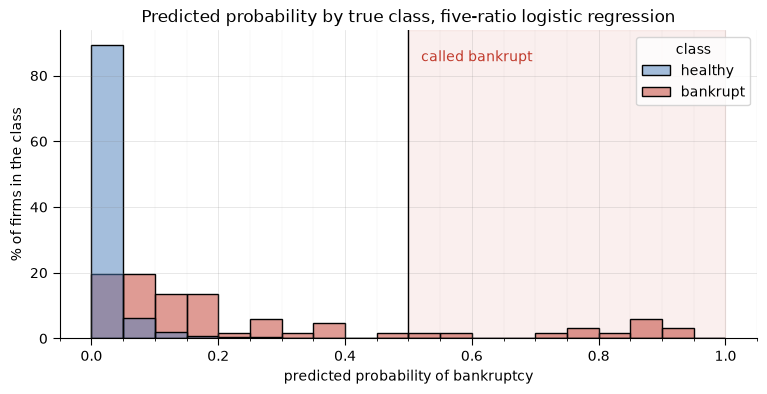

In [31]:
def draw_probabilities_by_class(probabilities, ax, title):
    """Overlaid histograms of predicted probability, healthy vs bankrupt firms."""
    plot_table = pd.DataFrame({
        "probability": probabilities,
        "class": np.where(y_test.to_numpy() == 1, "bankrupt", "healthy"),
    })
    ax.axvspan(
        0.5,
        1,
        color=BANKRUPT_COLOR,
        alpha=0.08,
    )
    sns.histplot(
        data=plot_table,
        x="probability",
        hue="class",
        stat="percent",
        common_norm=False,
        bins=np.linspace(0, 1, 21),
        palette={"healthy": HEALTHY_COLOR, "bankrupt": BANKRUPT_COLOR},
        alpha=0.5,
        ax=ax,
    )
    ax.axvline(0.5, color="black", linewidth=1)
    ax.text(
        0.52,
        ax.get_ylim()[1] * 0.9,
        "called bankrupt",
        color=BANKRUPT_COLOR,
    )
    ax.set_title(title)
    ax.set_xlabel("predicted probability of bankruptcy")
    ax.set_ylabel("% of firms in the class")
    make_ax_better(ax, minor="x")


fig, ax = plt.subplots(figsize=(9, 4))
draw_probabilities_by_class(
    five_logit.predict_proba(five_test)[:, 1],
    ax,
    "Predicted probability by true class, five-ratio logistic regression",
)
plt.show()

About one bankrupt firm in five gets under 5%, just like the healthy ones: the five ratios can't see it at all. Most of the rest get 5–40%: far higher than almost any healthy firm, but still left of the 0.5 line. The model *does* rank them as riskier. The rule "bankrupt only above 50%" throws that away.

**One cure: class weights.** Tell the model that the rare class matters as much as the common one: all bankrupt firms together weigh as much as all healthy firms together. In `scikit-learn` it is one argument.

In [32]:
weighted_logit = LogisticRegression(class_weight="balanced").fit(five_train, y_train)
count_verdicts(weighted_logit.predict(five_test))

{'accuracy': 0.863, 'caught': 57, 'missed': 9, 'false_alarms': 272}

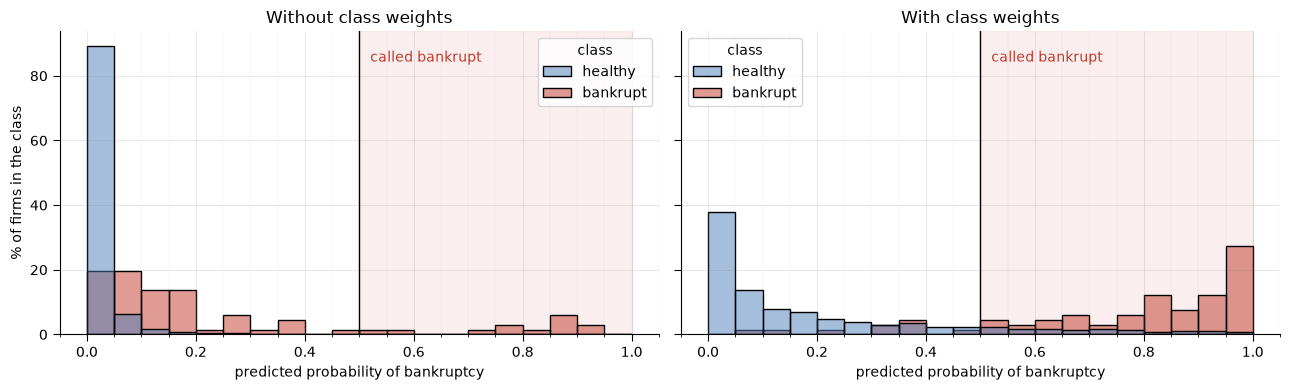

In [33]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4),
    sharey=True,
)
draw_probabilities_by_class(
    five_logit.predict_proba(five_test)[:, 1],
    axes[0],
    "Without class weights",
)
draw_probabilities_by_class(
    weighted_logit.predict_proba(five_test)[:, 1],
    axes[1],
    "With class weights",
)
plt.tight_layout()
plt.show()

With weights, the whole picture slides right: the bankrupt firms move past the line, and so does a tail of healthy firms. Accuracy drops to **86%**, but the model now catches **57 of 66** bankruptcies. The price: **272 false alarms**, healthy firms called bankrupt.

Put the three side by side:

In [34]:
comparison = pd.DataFrame(
    [
        count_verdicts(everyone_healthy),
        count_verdicts(five_logit.predict(five_test)),
        count_verdicts(weighted_logit.predict(five_test)),
    ],
    index=["everyone healthy", "logistic, five ratios", "logistic + class weights"],
)
comparison

,accuracy,caught,missed,false_alarms
everyone healthy,0.968,0,66,0
"logistic, five ratios",0.969,12,54,9
logistic + class weights,0.863,57,9,272


**Which is better?** The one with the higher accuracy catches 12 bankruptcies; the one with the lower accuracy catches 57. The answer depends on what a missed bankruptcy costs compared with a false alarm. That is exactly next week's question.

## 12. ⏭ Are class weights always good? Recall and precision

Class weights made the model catch far more bankruptcies, so it is tempting to switch them on every time. Before you do, split accuracy into the two questions a bank really asks:

- **recall**: of all firms that really went bankrupt, what share did we catch?

$$\text{recall} = \frac{\text{caught}}{\text{caught} + \text{missed}}$$

- **precision**: of all firms we *called* bankrupt, what share really went bankrupt?

$$\text{precision} = \frac{\text{caught}}{\text{caught} + \text{false alarms}}$$

Recall is what the risk team worries about: defaults that walk through. Precision is what the sales team worries about: good clients turned away for nothing.

🧪 **Toy example:** six made-up firms, two of them bankrupt; the model flags three.

In [35]:
toy_flags = pd.DataFrame({
    "actually_bankrupt": [1, 1, 0, 0, 0, 0],
    "called_bankrupt": [1, 0, 1, 1, 0, 0],
})
toy_is_bankrupt = toy_flags["actually_bankrupt"] == 1
toy_is_flagged = toy_flags["called_bankrupt"] == 1

toy_caught = (toy_is_flagged & toy_is_bankrupt).sum()
toy_missed = (~toy_is_flagged & toy_is_bankrupt).sum()
toy_false_alarms = (toy_is_flagged & ~toy_is_bankrupt).sum()

print(
    f"caught {toy_caught}, missed {toy_missed}, false alarms {toy_false_alarms}\n"
    f"recall:    {toy_caught / (toy_caught + toy_missed):.2f}\n"
    f"precision: {toy_caught / (toy_caught + toy_false_alarms):.2f}"
)
toy_flags

caught 1, missed 1, false alarms 2
recall:    0.50
precision: 0.33


,actually_bankrupt,called_bankrupt
0,1,1
1,1,0
2,0,1
3,0,1
4,0,0
5,0,0


By eye: of the two bankrupt firms the model caught one, so recall is 1/2. It raised three flags and one was right, so precision is 1/3.

**Back to the real test firms.** The comparison table already has every count we need; two new columns turn them into rates.

In [36]:
flags_raised = comparison["caught"] + comparison["false_alarms"]
bankrupt_firms = comparison["caught"] + comparison["missed"]

comparison["recall"] = (comparison["caught"] / bankrupt_firms).round(2)
comparison["precision"] = (comparison["caught"] / flags_raised).round(2)
comparison

,accuracy,caught,missed,false_alarms,recall,precision
everyone healthy,0.968,0,66,0,0.00,NaN
"logistic, five ratios",0.969,12,54,9,0.18,0.57
logistic + class weights,0.863,57,9,272,0.86,0.17


(The "everyone healthy" row shows `NaN` for precision: it never raises a flag, so there is nothing to divide by.)

Read the last two rows:

- **Without weights:** recall 0.18, precision 0.57. The model rarely raises a flag, but more than half of its flags are real.
- **With weights:** recall 0.86, precision 0.17. It catches almost every bankruptcy, but **five flags out of six are false alarms**.

So class weights are not a free fix: **they buy recall with precision.** If a false alarm only means an extra hour of analyst review, that is a great deal. If it means turning away a good client and losing their business, 272 false alarms can cost more than the 45 extra bankruptcies they catch.

Weights also shift *every* probability upwards, which works much like lowering the 0.5 cut-off for all firms at once. Session 6 turns that dial directly, threshold by threshold, and puts a price on each point. Until then, when you use class weights, always report recall and precision side by side, never one without the other.

## Try it yourself

1. Swap one of the five ratios for another one you'd defend in front of a credit committee. Does its sign match your expectation? Is it significant? (If a ratio gets a weight near zero, look at its `describe()` first. A few columns run from 0 to 1 for most firms and jump to billions for some. Which ratios, and how many firms? HW2 Part 0 asks the same question of your own data.)
2. Drop `Retained Earnings to Total Assets` from the five and refit. What happens to the ROA weight, and why?
3. At the median debt ratio the model says 1.4%. Find the debt ratio where it says 10%. (Checking one value at a time? A one-row table needs `sm.add_constant(one_firm, has_constant="add")`, or statsmodels skips `const`: with one row every column looks constant.) How would you explain that number to a loan officer?

In [37]:
# your turn

## Recap

- Find the data's source page first. Here it told us `Net Income Flag` is broken and `Liability-Assets Flag` is honest.
- **Classification = one line between classes.** Altman did it by hand in 1968.
- A least-squares line on 0/1 gives impossible probabilities. **Logistic regression = the same weighted sum pushed through a sigmoid**, so every firm gets a probability between 0 and 1.
- Read the coefficients like a financier: sign, size after standardizing, p-value. Twins can make a significant coefficient point the wrong way.
- Banks use exactly this model because it can be explained and validated (Regulation 483-P).
- **With 3% bankrupt, accuracy flatters:** 96.9% catches 12 of 66. Class weights catch 57, at the price of 272 false alarms. Choosing between them needs the price of each mistake: session 6.
- ⏭ **Recall** = share of bankrupt firms caught; **precision** = share of flags that are real. Class weights buy recall with precision (0.86 and 0.17): report both, never one.

---

## ⚡ Extras — power tools, not required

**Odds ratios.** The *odds* are P(bankrupt) / P(healthy): a 20% risk is odds of 1 to 4. Bankers often read a logistic coefficient as an *odds ratio*: `np.exp(coefficient)` says how many times the odds of bankruptcy multiply when the ratio grows by one std.

In [38]:
np.exp(five_model.params.drop("const")).round(2)

Working Capital to Total Assets                            0.78
Retained Earnings to Total Assets                          1.20
ROA(C) before interest and depreciation before interest    0.31
Total Asset Turnover                                       0.53
Debt ratio %                                               2.98
dtype: float64

**Retained earnings alone.** On its own, RE/TA gets the negative weight finance expects. Next to ROA, its twin, the sign flips.

In [39]:
retained_alone = sm.Logit(
    y_train,
    sm.add_constant(five_train[["Retained Earnings to Total Assets"]]),
).fit(disp=0)
summarize_coefficients(retained_alone)

,coefficient,p_value
const,-3.5230,0.0
Retained Earnings to Total Assets,-0.4994,0.0
